<a href="https://colab.research.google.com/github/prnakyazze94/Data-608/blob/main/Story%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

 data source <https://www.ncei.noaa.gov/access/monitoring/tornadoes/>

<https://www.ncei.noaa.gov/access/monitoring/tornadoes/time-series/12/0?fatalities=false> \

<https://data.giss.nasa.gov/gistemp>

https://www.ncei.noaa.gov/stormevents/listevents.jsp?eventType=%28Z%29+Hurricane+%28Typhoon%29&beginDate_mm=12&beginDate_dd=01&beginDate_yyyy=2013&endDate_mm=12&endDate_dd=31#&endDate_yyyy=2025&hailfilter=0.00&tornfilter=0&windfilter=000&sort=DT&submitbutton=Search&statefips=-999%2CALL

In [2]:
%%writefile hurricane_data.py
import pandas as pd

# 1. Define the URLs
urls = [
    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Hurricane_typhoon2001-2004..xls",
    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Hurrica_typhoon2005_2012",
    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Hurrice_typhoon20213_2025"
]

# 2. Load and Combine Data
data_frames = []
for url in urls:
    try:
        df = pd.read_csv(url, sep='\t')
        data_frames.append(df)
    except Exception as e:
        print(f"Error loading {url}: {e}")

hurricane_data_combined = pd.concat(data_frames, ignore_index=True)

# 3. Export the result to a CSV
hurricane_data_combined.to_csv("hurricane_combined.csv", index=False)
print("File 'hurricane_combined.csv' has been created successfully.")e_data.py

Writing hurricane_data.py


In [4]:
import pandas as pd
import numpy as np

# 1. Define the URLs from your repository
urls = {
    "2001_2004": "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Hurricane_typhoon2001-2004..xls",
    "2005_2012": "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Hurrica_typhoon2005_2012",
    "2013_2025": "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Hurrice_typhoon20213_2025"
}

data_frames = []

# 2. Load and Clean each file
for period, url in urls.items():
    try:
        # Note: GitHub 'raw' links serve text.
        # We use sep='\t' because these files appear to be tab-separated exports.
        df = pd.read_csv(url, sep='\t')

        # Standardize the 'Year' column if it exists, or extract from 'Date'
        if 'Date' in df.columns:
            df['Year'] = pd.to_datetime(df['Date'], errors='coerce').dt.year

        data_frames.append(df)
        print(f"Successfully loaded data for {period}")
    except Exception as e:
        print(f"Warning: Could not process {period}. Error: {e}")

# 3. Combine into one master dataframe
hurricane_combined = pd.concat(data_frames, ignore_index=True)

# 4. Ensure we have a continuous timeline (Handling the 2005 gap)
# We create a range of all years to make sure none are missing
all_years = pd.DataFrame({'Year': range(2000, 2026)})
final_df = all_years.merge(hurricane_combined, on='Year', how='left')

# Fill NaN with 0 for the counts so the '2005' data displays as 0 rather than a gap
final_df = final_df.fillna(0)

# 5. Save the file
final_df.to_csv("hurricane_combined.csv", index=False)

print("\n--- Process Complete ---")
print("File 'hurricane_combined.csv' created.")
print(f"Total records combined: {len(final_df)}")

Successfully loaded data for 2001_2004
Successfully loaded data for 2005_2012
Successfully loaded data for 2013_2025

--- Process Complete ---
File 'hurricane_combined.csv' created.
Total records combined: 880


In [6]:
import pandas as pd

# 1. URL to the raw data
url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/main/TotaL_TornadoeS_BY_MONTH"

# 2. Read the data
# We skip the first row since it contains the 'V1, V2, V3' labels
df = pd.read_csv(url, sep='\t', header=None, skiprows=1)
df.columns = ['Date', 'Tornadoes', 'Fatalities']

# 3. Clean 'Tornadoes'
df['Tornadoes'] = pd.to_numeric(df['Tornadoes'], errors='coerce')

# 4. Extract Year safely
# This takes the last 4 characters (the year) and handles errors
df['Year'] = pd.to_numeric(df['Date'].str[-4:], errors='coerce')
df = df.dropna(subset=['Year']) # Removes rows that aren't actual data
df['Year'] = df['Year'].astype(int)

# 5. Save to CSV
df.to_csv('tornado.csv', index=False)

print("File 'tornado.csv' has been created successfully.")
print(df.head())

File 'tornado.csv' has been created successfully.
       Date  Tornadoes  Fatalities  Year
0  Mar 2026     1271.0         NaN  2026
1  Feb 2026     1571.0         NaN  2026
2  Jan 2026     1562.0        67.0  2026
3  Dec 2025     1559.0        67.0  2025
4  Nov 2025     1670.0        68.0  2025


In [7]:
import pandas as pd

# 1. URL to the raw temperature data
temp_url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Land-Ocean_Temp"

# 2. Read the data
# sep=r'\s+' handles files where columns are separated by one or more spaces
temp_df = pd.read_csv(temp_url, sep=r'\s+')

# 3. Clean/Filter (Optional: keeping only Year and No_Smoothing as in your previous steps)
# If you want all columns, just skip this line
temp_df = temp_df[["Year", "No_Smoothing", "Lowess"]]

# 4. Save to CSV in your Colab files
temp_df.to_csv('temp_data.csv', index=False)

print("File 'temp_data.csv' has been created successfully.")
print(temp_df.head())

File 'temp_data.csv' has been created successfully.
   Year  No_Smoothing  Lowess
0  1880         -0.17   -0.10
1  1881         -0.09   -0.13
2  1882         -0.11   -0.17
3  1883         -0.18   -0.21
4  1884         -0.28   -0.24


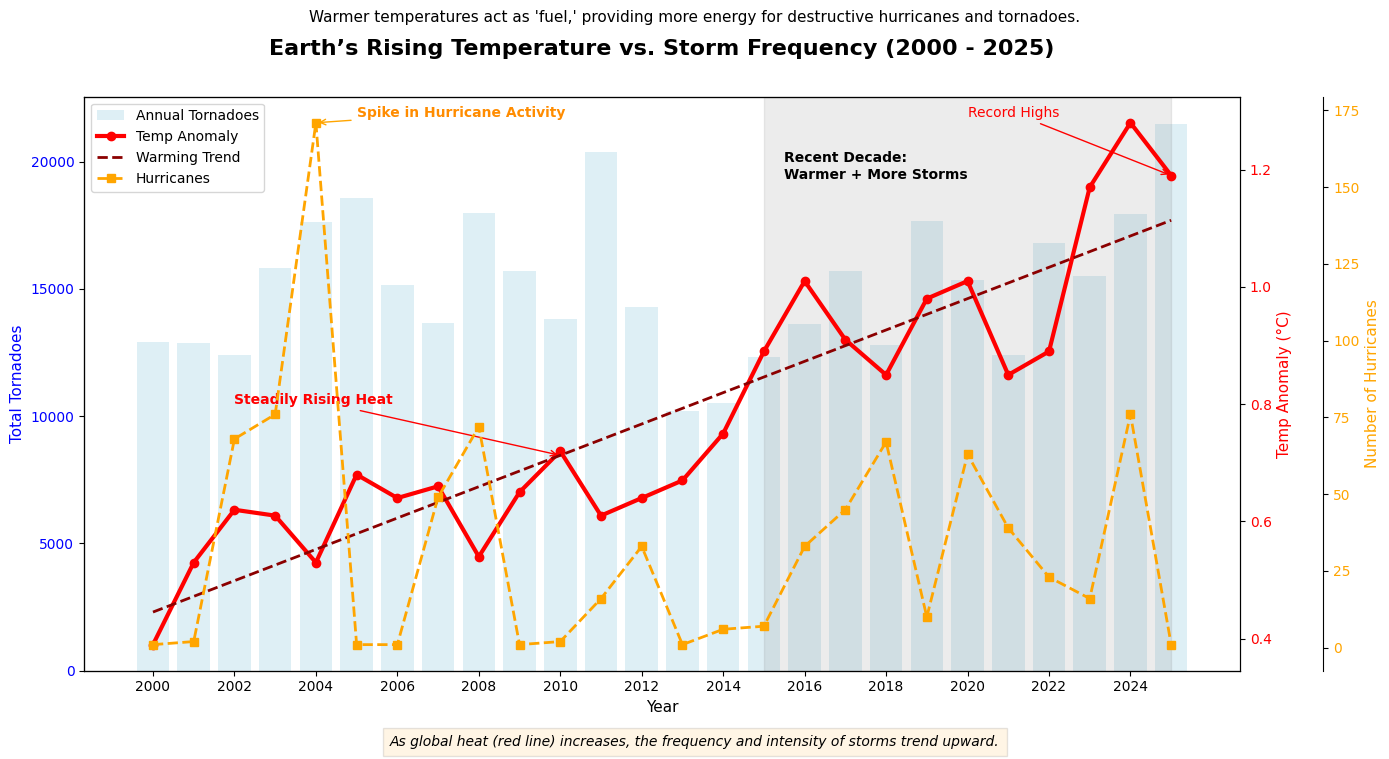

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
tornado_df = pd.read_csv('tornado.csv')
temp_df = pd.read_csv('temp_data.csv')
hurricane_df = pd.read_csv('hurricane_combined.csv')

# 2. Prepare data
tornado_annual = tornado_df.groupby('Year')['Tornadoes'].sum().reset_index()
temp_annual = temp_df[['Year', 'No_Smoothing']]

# Ensure Hurricane Year is extracted and counted
if 'Year' not in hurricane_df.columns:
    hurricane_df['Year'] = pd.to_datetime(hurricane_df['Date'], errors='coerce').dt.year
hurricane_annual = hurricane_df.groupby('Year').size().reset_index(name='Hurricane_Count')

# Merge and Fill Gaps
df = temp_annual.merge(tornado_annual, on='Year', how='left')
df = df.merge(hurricane_annual, on='Year', how='left')
df[['Tornadoes', 'Hurricane_Count']] = df[['Tornadoes', 'Hurricane_Count']].fillna(0)

# Filter for the specific 25-year period
df = df[(df['Year'] >= 2000) & (df['Year'] <= 2025)].sort_values('Year')

# 3. Plotting
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- Tornadoes (Background Context) ---
ax1.bar(df['Year'], df['Tornadoes'], color='lightblue', alpha=0.4, label='Annual Tornadoes')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Total Tornadoes', color='blue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='blue')

# --- Temperature (The "Why") ---
ax2 = ax1.twinx()
ax2.plot(df['Year'], df['No_Smoothing'], color='red', marker='o', linewidth=3, label='Temp Anomaly')
ax2.set_ylabel('Temp Anomaly (°C)', color='red', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')

# Temperature Trend Line
z = np.polyfit(df['Year'], df['No_Smoothing'], 1)
p = np.poly1d(z)
ax2.plot(df['Year'], p(df['Year']), color='darkred', linestyle='--', linewidth=2, label='Warming Trend')

# --- Hurricanes (The "Result") ---
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(df['Year'], df['Hurricane_Count'], color='orange', marker='s', linestyle='--', linewidth=2, label='Hurricanes')
ax3.set_ylabel('Number of Hurricanes', color='orange', fontsize=11)
ax3.tick_params(axis='y', labelcolor='orange')

# --- Storytelling Annotations ---

# 1. Highlight Recent Decade (Grey box)
ax1.axvspan(2015, 2025, color='gray', alpha=0.15)
ax1.text(2015.5, df['Tornadoes'].max()*0.9, "Recent Decade:\nWarmer + More Storms",
         fontsize=10, fontweight='bold', color='black')

# 2. Temperature Note
ax2.annotate("Steadily Rising Heat",
             xy=(2010, p(2010)), xytext=(2002, 0.8),
             arrowprops=dict(arrowstyle="->", color='red'), color='red', weight='bold')

# --- THE FIX: Updated Peak Hurricane Activity ---
peak_hurr_year = df.loc[df['Hurricane_Count'].idxmax(), 'Year']
peak_hurr_val = df['Hurricane_Count'].max()

# Changed text and moved xytext to the right of the point (peak_hurr_year+1)
ax3.annotate("Spike in Hurricane Activity",
             xy=(peak_hurr_year, peak_hurr_val), xytext=(peak_hurr_year+1, peak_hurr_val+2),
             arrowprops=dict(arrowstyle="->", color='orange'), color='darkorange', weight='bold')

# 4. Highest Temp Point
latest_yr = df.iloc[-1]
ax2.annotate("Record Highs",
             xy=(latest_yr['Year'], latest_yr['No_Smoothing']), xytext=(latest_yr['Year']-5, latest_yr['No_Smoothing']+0.1),
             arrowprops=dict(arrowstyle="->", color='red'), color='red')

# --- Titles & Legend ---
plt.title("Earth’s Rising Temperature vs. Storm Frequency (2000 - 2025)", fontsize=16, weight='bold', pad=30)
plt.suptitle("Warmer temperatures act as 'fuel,' providing more energy for destructive hurricanes and tornadoes.",
             fontsize=11, y=0.93)

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3, labels + labels2 + labels3, loc='upper left', frameon=True)

plt.xticks(np.arange(2000, 2026, 2))
plt.figtext(0.5, 0.01, "As global heat (red line) increases, the frequency and intensity of storms trend upward.",
            ha="center", fontsize=10, style='italic', bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_25256/2731906749.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hurricane_df['Year'] = pd.to_datetime(hurricane_df['Date'], errors='coerce').dt.year


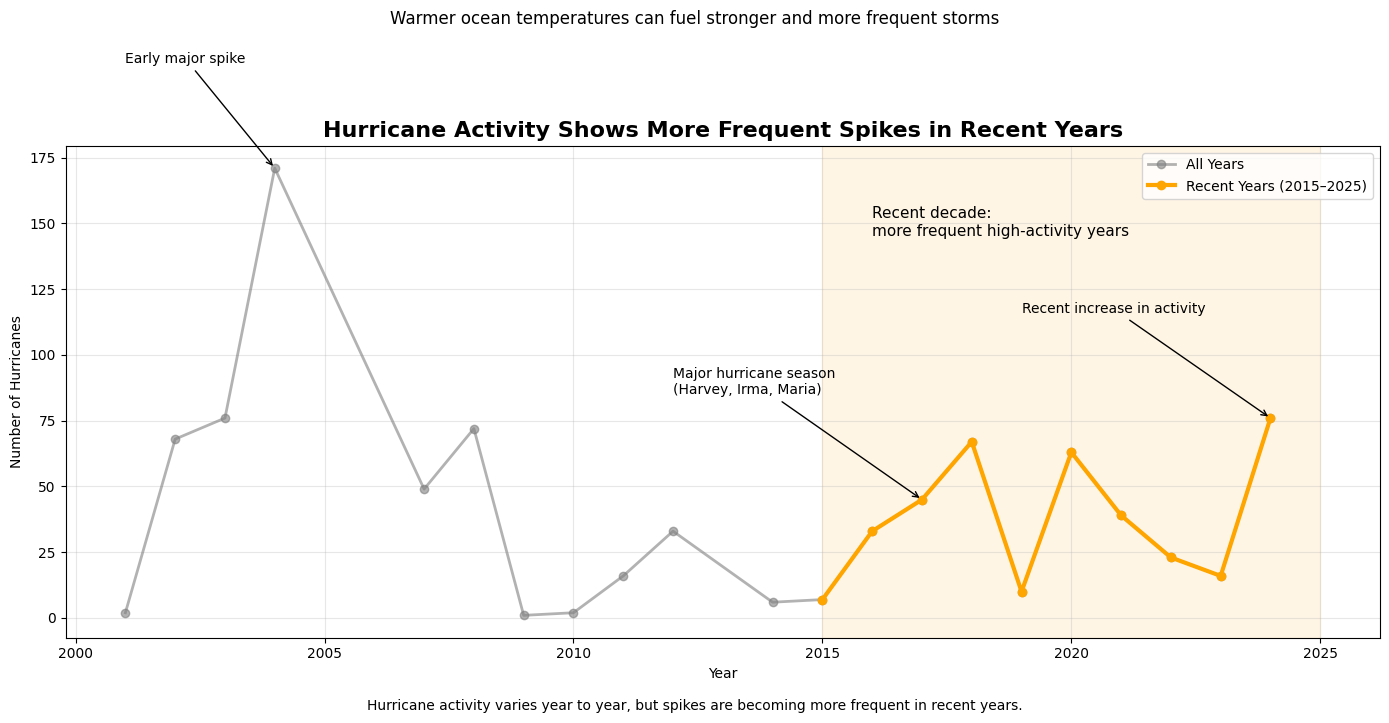

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
hurricane_df = pd.read_csv('hurricane_combined.csv')

# Extract year if needed
hurricane_df['Year'] = pd.to_datetime(hurricane_df['Date'], errors='coerce').dt.year

# Aggregate counts by year
hurricane_annual = hurricane_df.groupby('Year').size().reset_index(name='Hurricane_Count')

# Sort
hurricane_annual = hurricane_annual.sort_values('Year')

# --- Plot ---
plt.figure(figsize=(14, 7))

# Base line (muted for context)
plt.plot(
    hurricane_annual['Year'],
    hurricane_annual['Hurricane_Count'],
    color='gray',
    linewidth=2,
    marker='o',
    alpha=0.6,
    label='All Years'
)

# Highlight recent decade (2015–2025)
recent = hurricane_annual[hurricane_annual['Year'] >= 2015]
plt.plot(
    recent['Year'],
    recent['Hurricane_Count'],
    color='orange',
    linewidth=3,
    marker='o',
    label='Recent Years (2015–2025)'
)

# Shade recent decade
plt.axvspan(2015, 2025, color='orange', alpha=0.1)

# --- Annotations ---
# Early spike (example: 2004)
year_2004 = hurricane_annual[hurricane_annual['Year'] == 2004]
if not year_2004.empty:
    y_val = year_2004['Hurricane_Count'].values[0]
    plt.annotate(
        "Early major spike",
        xy=(2004, y_val),
        xytext=(2001, y_val + 40),
        arrowprops=dict(arrowstyle="->"),
        fontsize=10
    )

# 2017 major season
year_2017 = hurricane_annual[hurricane_annual['Year'] == 2017]
if not year_2017.empty:
    y_val = year_2017['Hurricane_Count'].values[0]
    plt.annotate(
        "Major hurricane season\n(Harvey, Irma, Maria)",
        xy=(2017, y_val),
        xytext=(2012, y_val + 40),
        arrowprops=dict(arrowstyle="->"),
        fontsize=10
    )

# Most recent spike
latest = hurricane_annual.iloc[-1]
plt.annotate(
    "Recent increase in activity",
    xy=(latest['Year'], latest['Hurricane_Count']),
    xytext=(latest['Year'] - 5, latest['Hurricane_Count'] + 40),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Label shaded region
plt.text(
    2016,
    hurricane_annual['Hurricane_Count'].max() * 0.85,
    "Recent decade:\nmore frequent high-activity years",
    fontsize=11
)

# --- Titles and labels ---
plt.title(
    "Hurricane Activity Shows More Frequent Spikes in Recent Years",
    fontsize=16,
    weight='bold'
)

plt.suptitle(
    "Warmer ocean temperatures can fuel stronger and more frequent storms",
    fontsize=12
)

plt.xlabel("Year")
plt.ylabel("Number of Hurricanes")

# Footnote / takeaway
plt.figtext(
    0.5, -0.02,
    "Hurricane activity varies year to year, but spikes are becoming more frequent in recent years.",
    ha='center',
    fontsize=10
)

# Grid and legend
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

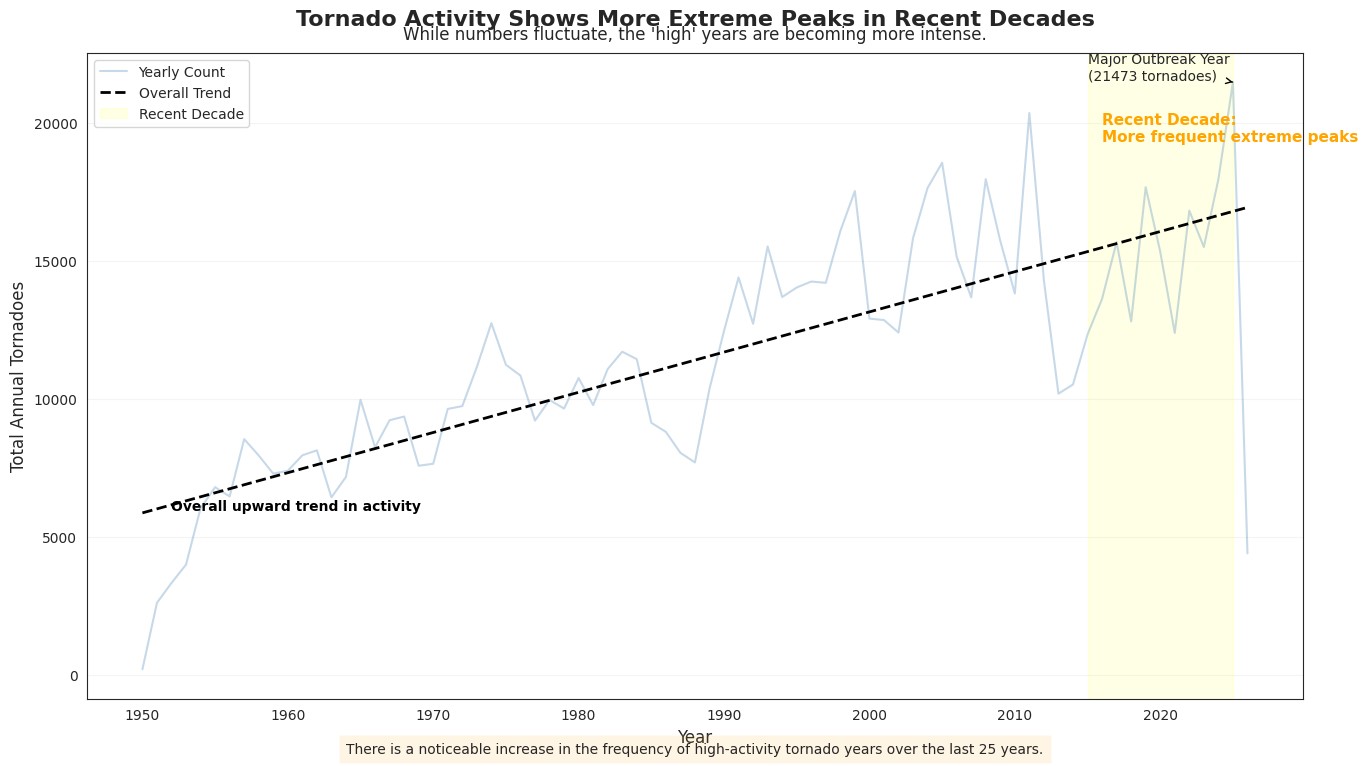

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data
# Assuming tornado_df has 'Year' and 'Tornadoes' columns
tornado_annual = tornado_df.groupby('Year')['Tornadoes'].sum().reset_index()
tornado_annual = tornado_annual.sort_values('Year')

# 2. Setup Plot
plt.figure(figsize=(14, 8))

# Background: Muted line for historical context
plt.plot(tornado_annual['Year'], tornado_annual['Tornadoes'],
         color='steelblue', alpha=0.3, linewidth=1.5, label='Yearly Count')

# 3. Add Trend Line (The "Message")
# Calculate a linear regression to show the general direction
z = np.polyfit(tornado_annual['Year'], tornado_annual['Tornadoes'], 1)
p = np.poly1d(z)
plt.plot(tornado_annual['Year'], p(tornado_annual['Year']),
         color='black', linestyle='--', linewidth=2, label='Overall Trend')

# 4. Highlight Recent Decade (2015-2025)
plt.axvspan(2015, 2025, color='yellow', alpha=0.1, label='Recent Decade')

# 5. Direct Annotations (Pointing to the Story)
# Label the Trend
plt.text(tornado_annual['Year'].min() + 2, p(tornado_annual['Year'].min()) + 100,
         "Overall upward trend in activity", color='black', fontweight='bold')

# Label a Major Peak (Example: Find the max year)
peak_year = tornado_annual.loc[tornado_annual['Tornadoes'].idxmax()]
plt.annotate(f"Major Outbreak Year\n({int(peak_year['Tornadoes'])} tornadoes)",
             xy=(peak_year['Year'], peak_year['Tornadoes']),
             xytext=(peak_year['Year']-10, peak_year['Tornadoes']+100),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10)

# Label the Shaded Region
plt.text(2016, tornado_annual['Tornadoes'].max() * 0.9,
         "Recent Decade:\nMore frequent extreme peaks",
         fontsize=11, color='orange', fontweight='bold')

# 6. Titles & Styling (High-School Accessible)
plt.title("Tornado Activity Shows More Extreme Peaks in Recent Decades",
          fontsize=16, pad=20, fontweight='bold')
plt.suptitle("While numbers fluctuate, the 'high' years are becoming more intense.",
             fontsize=12, y=0.92)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Annual Tornadoes", fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.legend(loc='upper left')

# Final Footer Takeaway
plt.figtext(0.5, 0.01,
            "There is a noticeable increase in the frequency of high-activity tornado years over the last 25 years.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

plt.tight_layout()
plt.show()

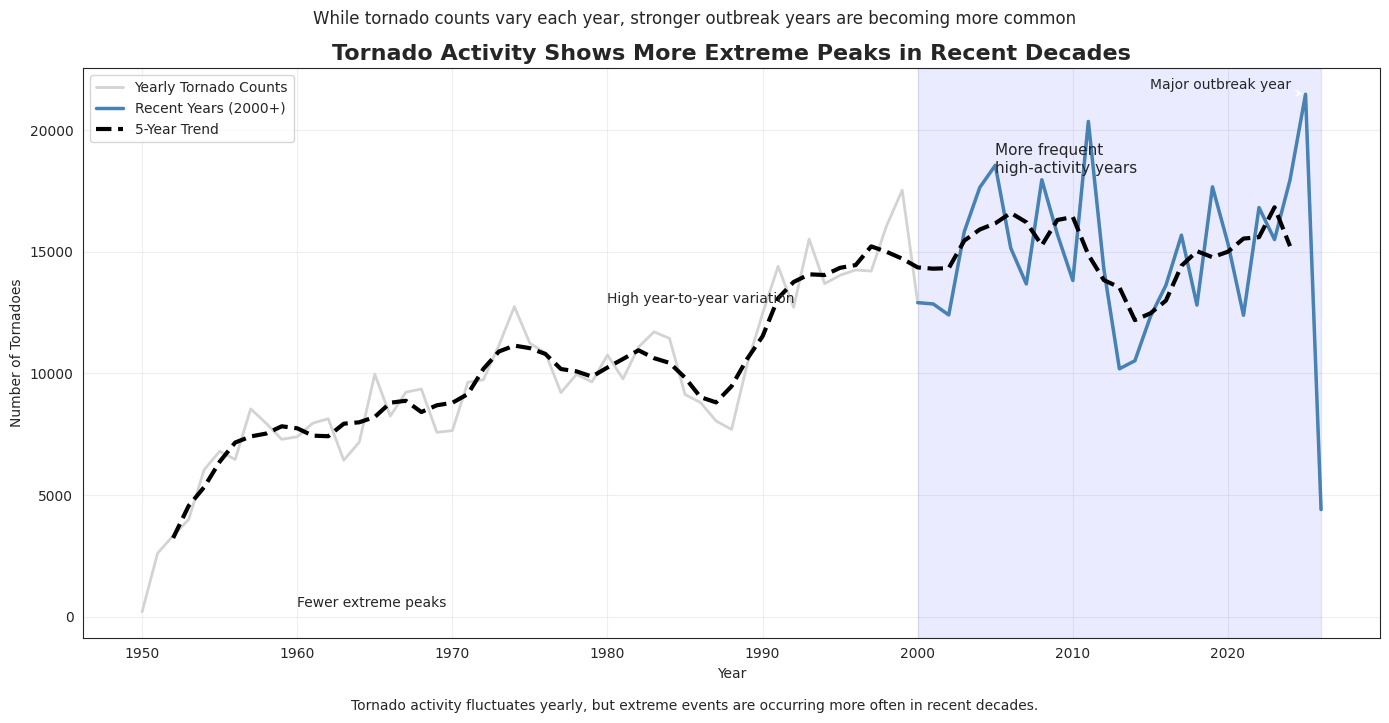

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
tornado_df = pd.read_csv('tornado.csv')

# Aggregate yearly totals (if needed)
tornado_annual = tornado_df.groupby('Year')['Tornadoes'].sum().reset_index()

# Sort
tornado_annual = tornado_annual.sort_values('Year')

# Create rolling average (trend line)
tornado_annual['Rolling_Avg'] = tornado_annual['Tornadoes'].rolling(window=5, center=True).mean()

# --- Plot ---
plt.figure(figsize=(14, 7))

# Background line (history)
plt.plot(
    tornado_annual['Year'],
    tornado_annual['Tornadoes'],
    color='lightgray',
    linewidth=2,
    label='Yearly Tornado Counts'
)

# Highlight recent years (2000+)
recent = tornado_annual[tornado_annual['Year'] >= 2000]
plt.plot(
    recent['Year'],
    recent['Tornadoes'],
    color='steelblue',
    linewidth=2.5,
    label='Recent Years (2000+)'
)

# Trend line (rolling average)
plt.plot(
    tornado_annual['Year'],
    tornado_annual['Rolling_Avg'],
    color='black',
    linestyle='--',
    linewidth=3,
    label='5-Year Trend'
)

# Highlight recent decades
plt.axvspan(2000, tornado_annual['Year'].max(), color='blue', alpha=0.08)

# --- Annotations ---
# Early period label
plt.text(
    1960,
    tornado_annual['Tornadoes'].min() + 200,
    "Fewer extreme peaks",
    fontsize=10
)

# Recent period label
plt.text(
    2005,
    tornado_annual['Tornadoes'].max() * 0.85,
    "More frequent\nhigh-activity years",
    fontsize=11
)

# Find and annotate a major peak
peak = tornado_annual.loc[tornado_annual['Tornadoes'].idxmax()]
plt.annotate(
    "Major outbreak year",
    xy=(peak['Year'], peak['Tornadoes']),
    xytext=(peak['Year'] - 10, peak['Tornadoes'] + 200),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Add explanation of variability
plt.text(
    1980,
    tornado_annual['Tornadoes'].max() * 0.6,
    "High year-to-year variation",
    fontsize=10
)

# --- Titles and labels ---
plt.title(
    "Tornado Activity Shows More Extreme Peaks in Recent Decades",
    fontsize=16,
    weight='bold'
)

plt.suptitle(
    "While tornado counts vary each year, stronger outbreak years are becoming more common",
    fontsize=12
)

plt.xlabel("Year")
plt.ylabel("Number of Tornadoes")

# Key takeaway (bottom note)
plt.figtext(
    0.5, -0.02,
    "Tornado activity fluctuates yearly, but extreme events are occurring more often in recent decades.",
    ha='center',
    fontsize=10
)

# Grid & legend
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

# The URL to the raw data
url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/GISTemp"

# 1. Read the file
# sep='\s+' tells pandas to treat any number of spaces as a delimiter
gistemp = pd.read_table(url, sep='\s+')

# 2. Display the first few rows (equivalent to head() in R)
print(gistemp.head())

# 3. Save the data to a local file
# Save as CSV
gistemp.to_csv("gistemp.csv", index=False)

# Or save as a text file to match the original style
gistemp.to_csv("gistemp.txt", sep='\t', index=False)

      Year  Anomaly
0  1880.04    -2.60
1  1880.13    -2.40
2  1880.21    -1.57
3  1880.29    -0.63
4  1880.38     0.37


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_25256/2422028415.py:8: SyntaxWarning: invalid escape sequence '\s'
  gistemp = pd.read_table(url, sep='\s+')


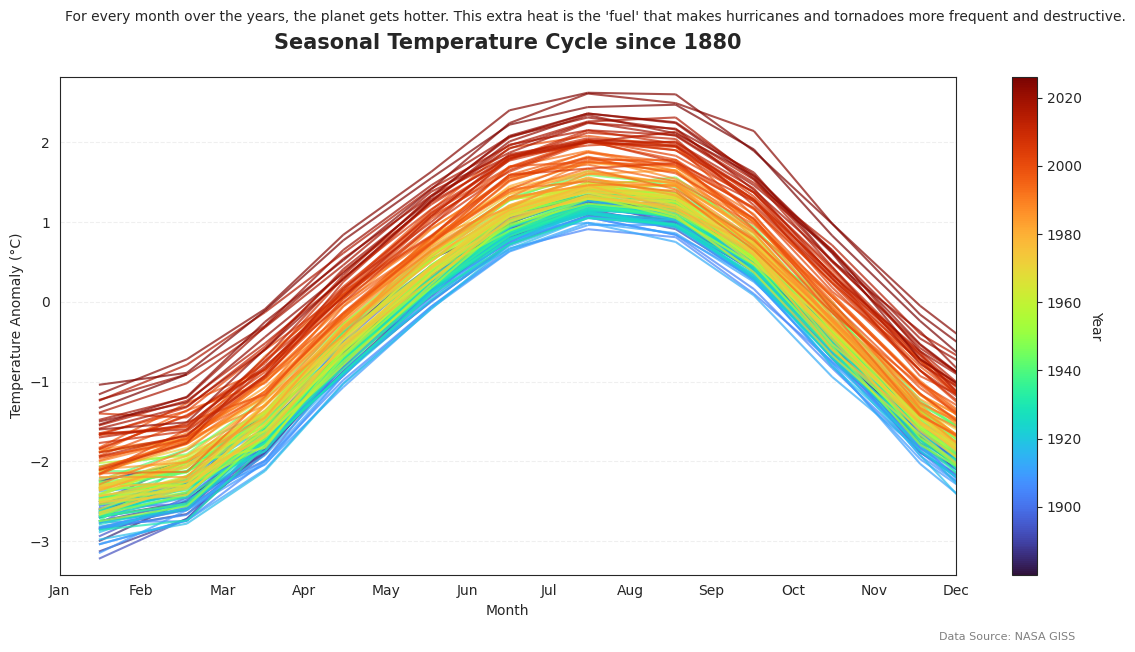

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.collections import LineCollection

# 1. Load and Clean
df = pd.read_csv('gistemp.csv')
df = df.sort_values('Year')

# 2. Setup the Figure
plt.figure(figsize=(12, 7))
sns.set_style("white")
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

# 3. Prepare Data for LineCollection
# Calculate Month (1-12) and Anomaly
x = (df['Year'] % 1) * 12 + 1
y = df['Anomaly']
years = df['Year']

# Create segments: (x1, y1) to (x2, y2)
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# --- THE FIX: Mask segments that cross from Dec (12) back to Jan (1) ---
# We check if the x-value of the next point is significantly smaller than the current
is_not_reset = np.diff(x) > 0
clean_segments = segments[is_not_reset]
clean_years = years[:-1][is_not_reset]

# 4. Create and add the LineCollection
norm = plt.Normalize(df['Year'].min(), df['Year'].max())
lc = LineCollection(clean_segments, cmap='turbo', norm=norm)
lc.set_array(clean_years)
lc.set_linewidth(1.5)
lc.set_alpha(0.7)

plt.gca().add_collection(lc)

# 5. Formatting Axes
plt.xlim(1, 12)
plt.ylim(df['Anomaly'].min() - 0.2, df['Anomaly'].max() + 0.2)

plt.title("Seasonal Temperature Cycle since 1880", fontweight='bold', fontsize=15, pad=20)
plt.suptitle("For every month over the years, the planet gets hotter. This extra heat is the 'fuel' that makes hurricanes and tornadoes more frequent and destructive.",
             fontsize=10, y=0.92)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.xticks(ticks=range(1, 13), labels=month_labels)
plt.xlabel("Month")
plt.ylabel("Temperature Anomaly (°C)")

# 6. Colorbar
sm = plt.cm.ScalarMappable(cmap="turbo", norm=norm)
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Year', rotation=270, labelpad=15)

plt.figtext(0.9, 0.02, "Data Source: NASA GISS", horizontalalignment='right', fontsize=8, color='gray')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

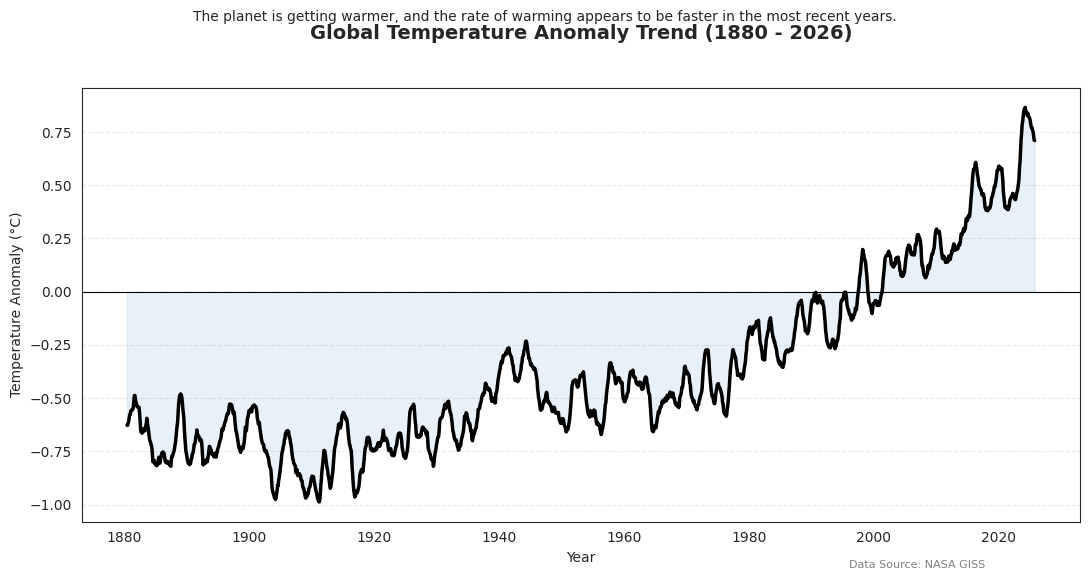

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and prepare data
df = pd.read_csv('gistemp.csv')
df = df.sort_values('Year')

# 2. Calculate the Trend
# We use a rolling mean to create a smooth 'curve' that
# filters out the noise of individual month fluctuations.
df['Smooth_Anomaly'] = df['Anomaly'].rolling(window=12, center=True).mean()

# 3. Plotting
plt.figure(figsize=(11, 6))
sns.set_style("white")

# Plot only the smoothed curve
# We use 'Year' as the X-axis to see the historical progression
plt.plot(df['Year'], df['Smooth_Anomaly'], color='black', linewidth=2.5, label='Smoothed Trend')

# Fill area under the curve for visual emphasis (optional)
plt.fill_between(df['Year'], df['Smooth_Anomaly'], color='#1f77b4', alpha=0.1)

# 4. Formatting
# 1. Add 'pad' to the title to push the plot down
plt.title("Global Temperature Anomaly Trend (1880 - 2026)",
          fontweight='bold',
          fontsize=14,
          pad=35) # Increase this number if they still touch

# 2. Use 'y' to position the suptitle higher up
plt.suptitle("The planet is getting warmer, and the rate of warming appears to be faster in the most recent years.",
             fontsize=10,
             y=0.95) # Values between 0.92 and 0.98 usually work best

# 3. Ensure tight_layout has room for the top titles
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.ylabel("Temperature Anomaly (°C)")
plt.xlabel("Year")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

# Highlight the 0°C baseline
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')

# Add Source
plt.figtext(0.9, 0.02, "Data Source: NASA GISS", horizontalalignment='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

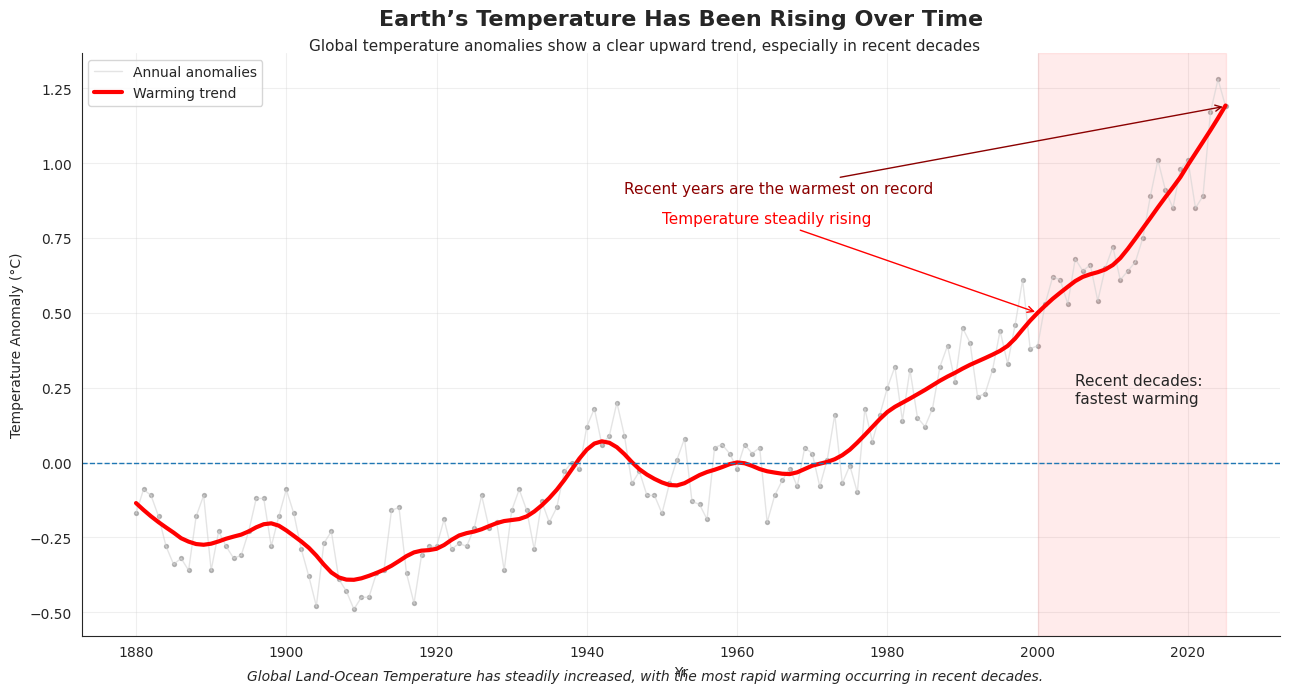

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Load data
temp_data = pd.read_csv("temp_data.csv")

# LOWESS smoothing
lowess_smoothed = lowess(
    temp_data["No_Smoothing"],
    temp_data["Year"],
    frac=0.1
)

# Plot
fig, ax = plt.subplots(figsize=(13, 7))

# Raw data
ax.plot(
    temp_data["Year"],
    temp_data["No_Smoothing"],
    color="lightgray",
    alpha=0.6,
    linewidth=1,
    label="Annual anomalies"
)

ax.scatter(
    temp_data["Year"],
    temp_data["No_Smoothing"],
    color="gray",
    s=8,
    alpha=0.5
)

# Trend line
ax.plot(
    lowess_smoothed[:, 0],
    lowess_smoothed[:, 1],
    color="red",
    linewidth=3,
    label="Warming trend"
)

# Baseline reference
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

# Highlight recent warming period
ax.axvspan(2000, temp_data["Year"].max(), color="red", alpha=0.08)

# ---- CUES / ANNOTATIONS ----
# Warming trend cue
ax.annotate(
    "Temperature steadily rising",
    xy=(2000, 0.5),
    xytext=(1950, 0.8),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11,
    color="red"
)

# Record highs
latest = temp_data.iloc[-1]

ax.annotate(
    "Recent years are the warmest on record",
    xy=(latest["Year"], latest["No_Smoothing"]),
    xytext=(1945, 0.9),   # moved left and lower
    arrowprops=dict(arrowstyle="->", color="darkred"),
    fontsize=11,
    color="darkred",
    ha="left"
)

# Highlight modern warming
ax.text(
    2005,
    0.2,
    "Recent decades:\nfastest warming",
    fontsize=11
)

# Title
ax.set_title(
    "Earth’s Temperature Has Been Rising Over Time",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Subtitle
fig.text(
    0.5,
    0.92,
    "Global temperature anomalies show a clear upward trend, especially in recent decades",
    ha="center",
    fontsize=11
)

# Labels
ax.set_xlabel("Yr")
ax.set_ylabel("Temperature Anomaly (°C)")

# Key takeaway footer
fig.text(
    0.5,
    0.02,
    "Global Land-Ocean Temperature has steadily increased, with the most rapid warming occurring in recent decades.",
    ha="center",
    fontsize=10,
    style="italic"
)

# Minimal style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()